Saved fig1_concept.pdf


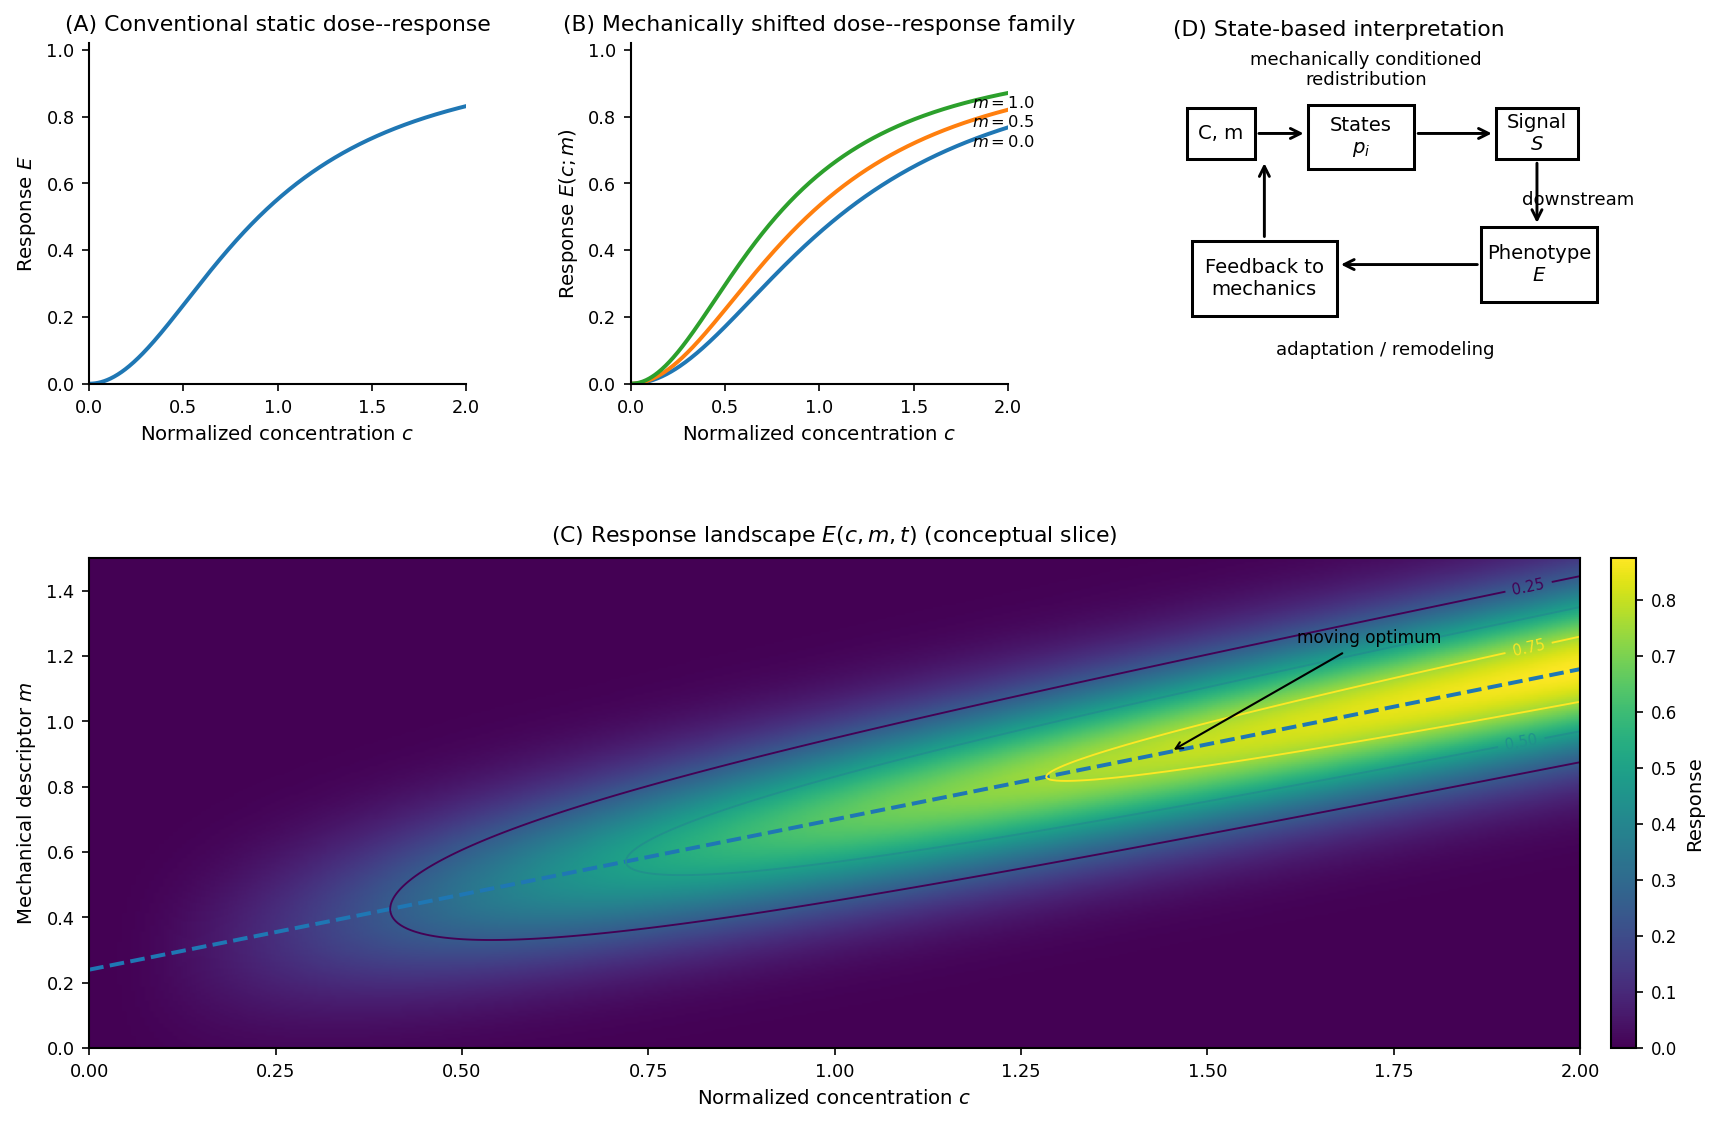

In [20]:
# fig1_concept.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def hill(c, ec50=1.0, n=2.0):
    return c**n / (ec50**n + c**n)

# -------------------------
# layout
# -------------------------
fig = plt.figure(figsize=(11.6, 7.7))
gs = GridSpec(
    2, 3, figure=fig,
    height_ratios=[0.82, 1.18],
    width_ratios=[1.0, 1.0, 1.28],
    hspace=0.42, wspace=0.40
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axD = fig.add_subplot(gs[0, 2])
axC = fig.add_subplot(gs[1, :])

# -------------------------
# Panel A
# -------------------------
c = np.linspace(0.0, 2.0, 500)
yA = hill(c, ec50=0.90, n=2.0)

axA.plot(c, yA, lw=1.9)
axA.set_xlim(0, 2.0)
axA.set_ylim(0, 1.02)
axA.set_xlabel("Normalized concentration $c$")
axA.set_ylabel("Response $E$")
axA.set_title("(A) Conventional static dose--response", pad=6)
axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)

# -------------------------
# Panel B
# -------------------------
m_values = [0.0, 0.5, 1.0]
curves = []
for m in m_values:
    ec50 = 1.10 - 0.33 * m
    y = hill(c, ec50=ec50, n=2.0)
    curves.append((m, y))
    axB.plot(c, y, lw=1.9)

axB.set_xlim(0, 2.0)
axB.set_ylim(0, 1.02)
axB.set_xlabel("Normalized concentration $c$")
axB.set_ylabel("Response $E(c;m)$")
axB.set_title("(B) Mechanically shifted dose--response family", pad=6)
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)

x_lab = 1.78
for m, y in curves:
    y_lab = np.interp(x_lab, c, y)
    axB.text(x_lab + 0.03, y_lab, fr"$m={m:.1f}$", va="center", fontsize=7.8)

# -------------------------
# Panel D
# -------------------------
axD.set_axis_off()
axD.set_xlim(0, 1)
axD.set_ylim(0, 1)

# manual title placement so it aligns visually with A/B
axD.text(
    0.00, 1.01,
    "(D) State-based interpretation",
    transform=axD.transAxes,
    ha="left", va="bottom",
    fontsize=10.5
)

box_lw = 1.45
text_fs = 9.4
anno_fs = 8.7

boxes = {
    "C, m":                    (0.03, 0.66, 0.14, 0.15),
    "States\n$p_i$":           (0.28, 0.63, 0.22, 0.19),
    "Signal\n$S$":             (0.67, 0.66, 0.17, 0.15),
    "Phenotype\n$E$":          (0.64, 0.24, 0.24, 0.22),
    "Feedback to\nmechanics":  (0.04, 0.20, 0.30, 0.22),
}

for label, (x, y, w, h) in boxes.items():
    axD.add_patch(Rectangle((x, y), w, h, fill=False, lw=box_lw))
    axD.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=text_fs)

arrow_kw = dict(arrowstyle="->", mutation_scale=12, lw=1.4)

# main path
axD.add_patch(FancyArrowPatch((0.17, 0.735), (0.28, 0.735), **arrow_kw))
axD.add_patch(FancyArrowPatch((0.50, 0.735), (0.67, 0.735), **arrow_kw))
axD.add_patch(FancyArrowPatch((0.755, 0.66), (0.755, 0.46), **arrow_kw))

# feedback loop
axD.add_patch(FancyArrowPatch((0.64, 0.35), (0.34, 0.35), **arrow_kw))
axD.add_patch(FancyArrowPatch((0.19, 0.42), (0.19, 0.66), **arrow_kw))

# annotations
axD.text(
    0.40, 0.865,
    "mechanically conditioned\nredistribution",
    ha="center", va="bottom", fontsize=anno_fs
)

axD.text(
    0.84, 0.54,
    "downstream",
    ha="center", va="center", fontsize=anno_fs
)

axD.text(
    0.44, 0.10,
    "adaptation / remodeling",
    ha="center", va="center", fontsize=anno_fs
)

# -------------------------
# Panel C
# -------------------------
c_grid = np.linspace(0.0, 2.0, 320)
m_grid = np.linspace(0.0, 1.5, 240)
C, M = np.meshgrid(c_grid, m_grid)

m_star = 0.24 + 0.46 * C
E = (C**1.9 / (0.72**1.9 + C**1.9)) * np.exp(-((M - m_star)**2) / (2 * 0.18**2))

im = axC.imshow(
    E,
    origin="lower",
    aspect="auto",
    extent=[0, 2, 0, 1.5],
)

axC.plot(c_grid, 0.24 + 0.46 * c_grid, "--", lw=1.9)
contours = axC.contour(C, M, E, levels=[0.25, 0.50, 0.75], linewidths=0.9)
axC.clabel(contours, fmt="%.2f", fontsize=7, inline=True)

axC.set_xlim(0, 2.0)
axC.set_ylim(0, 1.5)
axC.set_xlabel("Normalized concentration $c$")
axC.set_ylabel("Mechanical descriptor $m$")
axC.set_title("(C) Response landscape $E(c, m,t)$ (conceptual slice)", pad=8)

axC.annotate(
    "moving optimum",
    xy=(1.45, 0.24 + 0.46 * 1.45),
    xytext=(1.62, 1.24),
    arrowprops=dict(arrowstyle="->", lw=1.0),
    fontsize=8.2,
    ha="left"
)

cb = fig.colorbar(im, ax=axC, fraction=0.028, pad=0.02)
cb.set_label("Response")
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.07, right=0.97)

fig.savefig("fig1_concept.pdf")
print("Saved fig1_concept.pdf")
plt.show()

Saved fig2_two_state.pdf


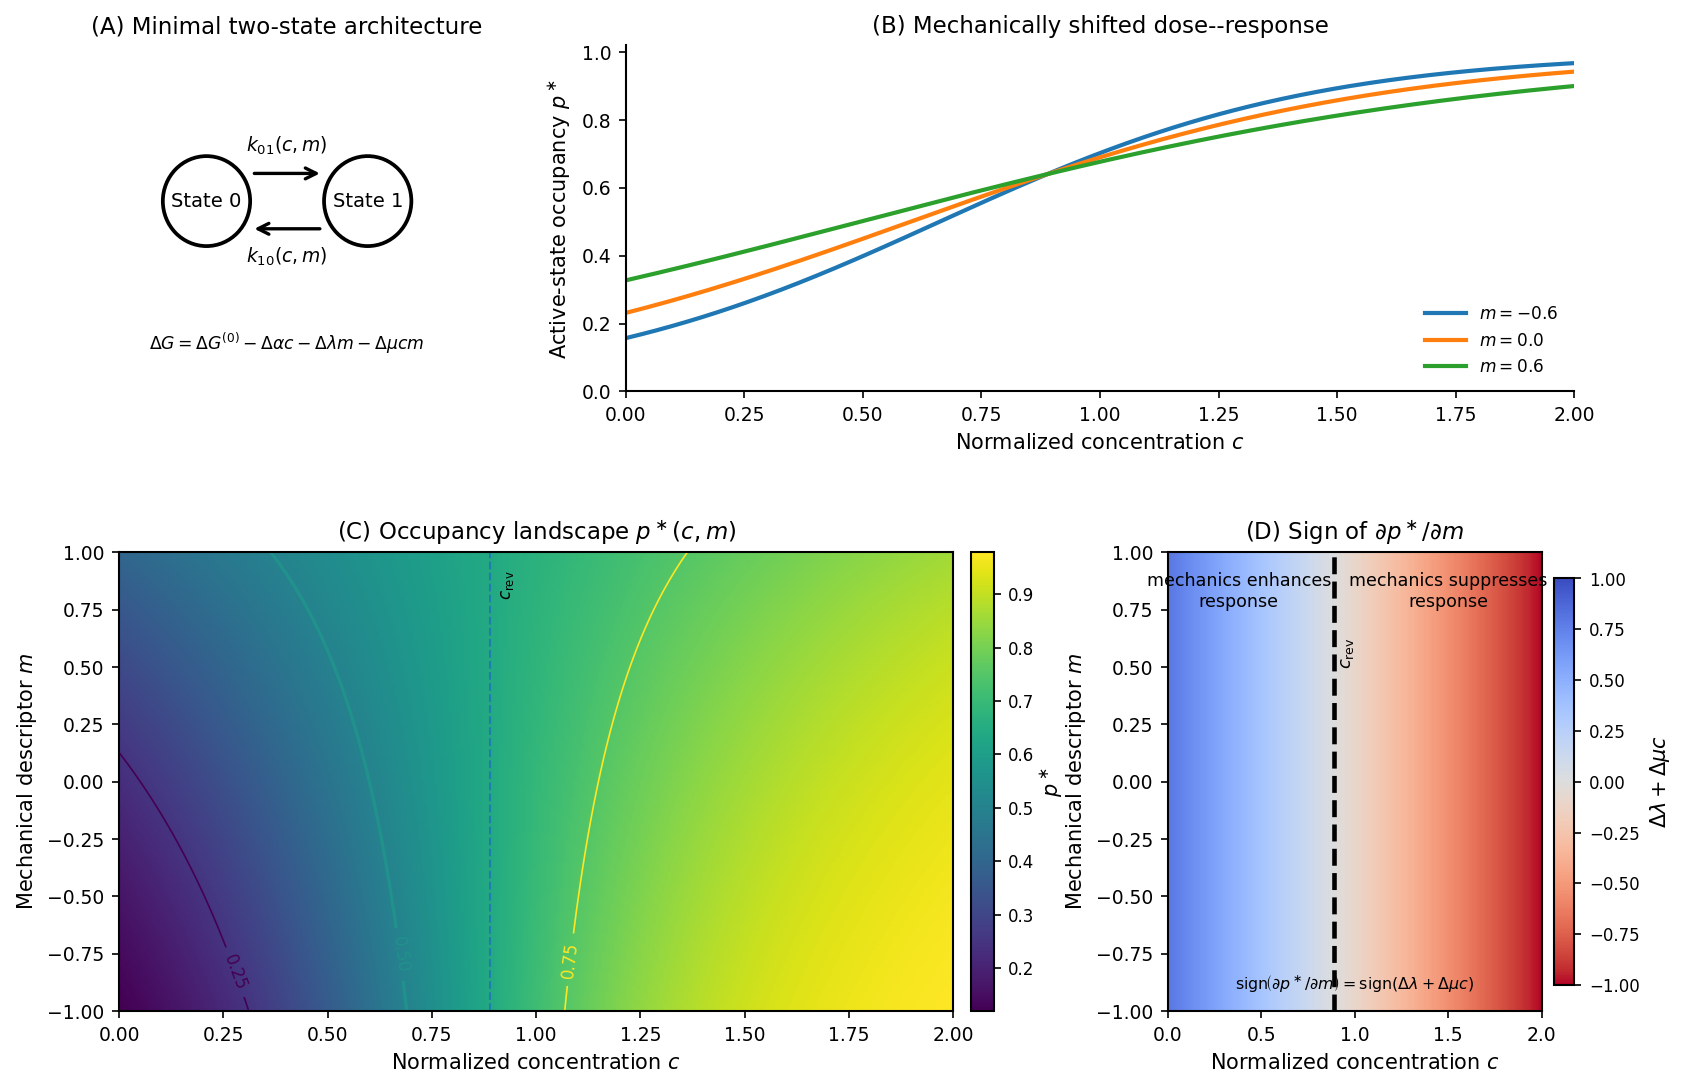

In [21]:
# fig2_two_state.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

beta = 1.0
DG0 = 1.2
Da = 2.0
Dl = 0.8
Dm = -0.9

def delta_G(c, m):
    return DG0 - Da * c - Dl * m - Dm * c * m

def pstar(c, m):
    return 1.0 / (1.0 + np.exp(beta * delta_G(c, m)))

def mech_sensitivity_prefactor(c):
    return Dl + Dm * c

c_rev = -Dl / Dm

fig = plt.figure(figsize=(10.9, 7.4))
gs = GridSpec(
    2, 3, figure=fig,
    height_ratios=[0.86, 1.14],
    width_ratios=[0.95, 1.05, 1.15],
    hspace=0.40, wspace=0.46
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1:])
axC = fig.add_subplot(gs[1, 0:2])
axD = fig.add_subplot(gs[1, 2])

# (A)
axA.set_title("(A) Minimal two-state architecture", pad=6)
axA.axis("off")
axA.set_xlim(0, 1)
axA.set_ylim(0, 1)

r = 0.13
for x, label in [(0.26, "State 0"), (0.74, "State 1")]:
    axA.add_patch(Circle((x, 0.55), r, fill=False, lw=1.8))
    axA.text(x, 0.55, label, ha="center", va="center", fontsize=9.4)

axA.add_patch(FancyArrowPatch((0.39, 0.63), (0.61, 0.63),
                              arrowstyle="->", mutation_scale=13, lw=1.6))
axA.add_patch(FancyArrowPatch((0.61, 0.47), (0.39, 0.47),
                              arrowstyle="->", mutation_scale=13, lw=1.6))

axA.text(0.50, 0.71, r"$k_{01}(c,m)$", ha="center", va="center", fontsize=9)
axA.text(0.50, 0.39, r"$k_{10}(c,m)$", ha="center", va="center", fontsize=9)
axA.text(
    0.50, 0.14,
    r"$\Delta G=\Delta G^{(0)}-\Delta\alpha c-\Delta\lambda m-\Delta\mu cm$",
    ha="center", va="center", fontsize=8.3
)

# (B)
axB.set_title("(B) Mechanically shifted dose--response", pad=6)

c = np.linspace(0.0, 2.0, 500)
m_values = [-0.6, 0.0, 0.6]

for m in m_values:
    y = pstar(c, m)
    axB.plot(c, y, lw=2.0, label=fr"$m={m:.1f}$")

axB.set_xlabel("Normalized concentration $c$")
axB.set_ylabel(r"Active-state occupancy $p^\ast$")
axB.set_xlim(0, 2.0)
axB.set_ylim(0, 1.02)
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.legend(frameon=False, loc="lower right", handlelength=2.4)

# shared grids
c_grid = np.linspace(0.0, 2.0, 280)
m_grid = np.linspace(-1.0, 1.0, 260)
C, M = np.meshgrid(c_grid, m_grid)
P = pstar(C, M)

# (C)
axC.set_title(r"(C) Occupancy landscape $p^\ast(c,m)$", pad=6)

imC = axC.imshow(
    P,
    origin="lower",
    aspect="auto",
    extent=[c_grid.min(), c_grid.max(), m_grid.min(), m_grid.max()],
)

levels = [0.25, 0.50, 0.75]
linewidths = [0.8, 1.6, 0.8]
cs = axC.contour(C, M, P, levels=levels, linewidths=linewidths)
axC.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

axC.axvline(c_rev, ls="--", lw=1.0, alpha=0.9)
axC.text(
    c_rev + 0.02, 0.92,
    r"$c_{\mathrm{rev}}$",
    rotation=90, va="top", fontsize=8
)

axC.set_xlabel("Normalized concentration $c$")
axC.set_ylabel("Mechanical descriptor $m$")
axC.set_xlim(0, 2.0)
axC.set_ylim(-1.0, 1.0)

cbC = fig.colorbar(imC, ax=axC, fraction=0.030, pad=0.020)
cbC.set_label(r"$p^\ast$", labelpad=2)
cbC.ax.tick_params(labelsize=8)

# (D)
axD.set_title(r"(D) Sign of $\partial p^\ast/\partial m$", pad=6)

pref = mech_sensitivity_prefactor(C)
vmax = np.max(np.abs(pref))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

imD = axD.imshow(
    pref,
    origin="lower",
    aspect="auto",
    extent=[c_grid.min(), c_grid.max(), m_grid.min(), m_grid.max()],
    cmap="coolwarm_r",
    norm=norm
)

axD.axvline(c_rev, ls="--", lw=2.2, color="black")
axD.text(
    c_rev + 0.02, 0.56,
    r"$c_{\mathrm{rev}}$",
    rotation=90, va="center", ha="left",
    fontsize=8.6, color="black"
)

axD.text(
    0.38, 0.83,
    "mechanics enhances\nresponse",
    ha="center", va="center", fontsize=8.4, color="black"
)
axD.text(
    1.50, 0.83,
    "mechanics suppresses\nresponse",
    ha="center", va="center", fontsize=8.4, color="black"
)

axD.text(
    1.00, -0.88,
    r"$\mathrm{sign}\!\left(\partial p^\ast/\partial m\right)=\mathrm{sign}(\Delta\lambda+\Delta\mu c)$",
    ha="center", va="center", fontsize=7.6, color="black"
)

axD.set_xlabel("Normalized concentration $c$")
axD.set_ylabel("Mechanical descriptor $m$")
axD.set_xlim(0, 2.0)
axD.set_ylim(-1.0, 1.0)

cbD = fig.colorbar(imD, ax=axD, fraction=0.050, pad=0.03)
cbD.set_label(r"$\Delta\lambda+\Delta\mu c$")
cbD.ax.tick_params(labelsize=8)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.97)

fig.savefig("fig2_two_state.pdf")
print("Saved fig2_two_state.pdf")
plt.show()

Saved fig3_three_state.pdf


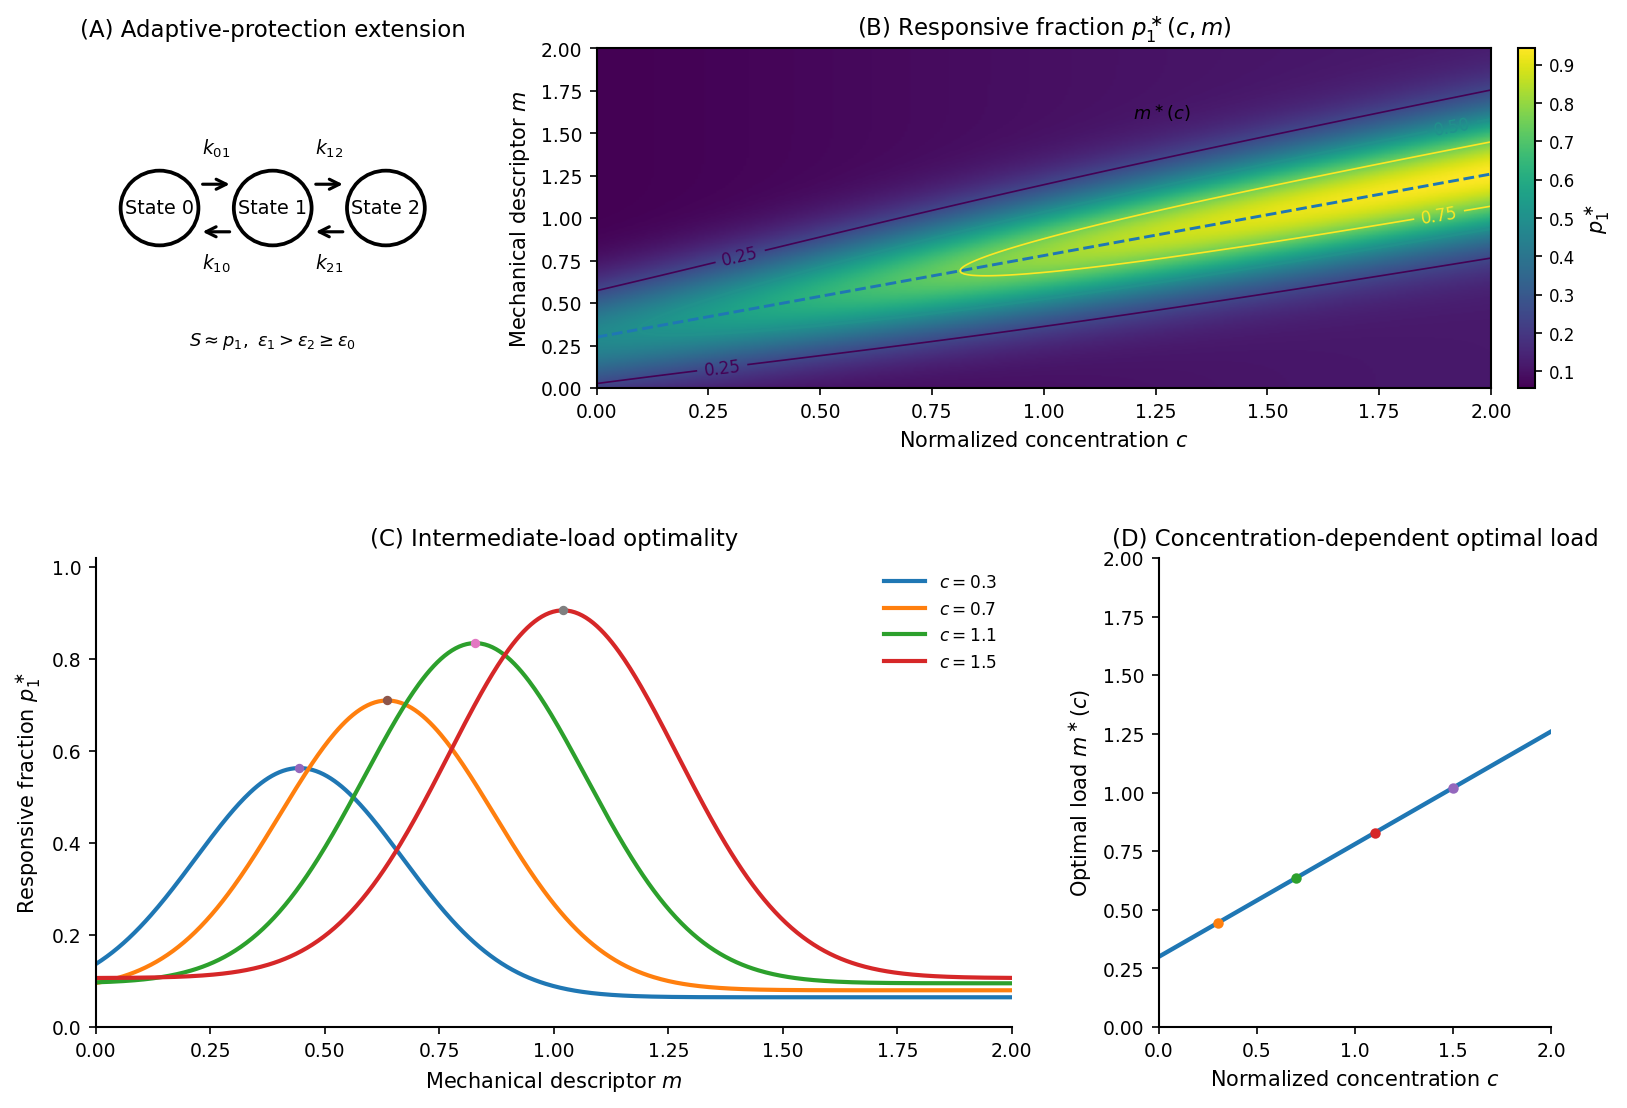

In [22]:
# fig3_three_state.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------------
# phenomenological three-state steady-state model
# p1*(c,m) has an interior optimum in m, and the optimal load shifts with c
# -------------------------
def p1_star(c, m):
    # bell-shaped response in m with concentration-dependent optimum
    mopt = 0.30 + 0.48 * c
    amp = 0.58 + 0.26 * np.tanh(1.3 * (c - 0.55))
    width = 0.22 + 0.02 * c
    baseline = 0.08 + 0.04 * np.tanh(1.0 * (c - 0.7))
    return baseline + amp * np.exp(-((m - mopt) ** 2) / (2 * width ** 2))

def optimal_load(c):
    return 0.30 + 0.48 * c

# grids
c_grid = np.linspace(0.0, 2.0, 300)
m_grid = np.linspace(0.0, 2.0, 260)
C, M = np.meshgrid(c_grid, m_grid)
P1 = p1_star(C, M)
MOPT = optimal_load(c_grid)

# -------------------------
# layout
# top: A, B
# bottom: C emphasized, D companion
# -------------------------
fig = plt.figure(figsize=(10.9, 7.5))
gs = GridSpec(
    2, 3, figure=fig,
    height_ratios=[0.84, 1.16],
    width_ratios=[0.92, 1.08, 1.02],
    hspace=0.42, wspace=0.38
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1:])
axC = fig.add_subplot(gs[1, 0:2])
axD = fig.add_subplot(gs[1, 2])

# -------------------------
# (A) Adaptive-protection extension
# -------------------------
axA.set_title("(A) Adaptive-protection extension", pad=6)
axA.axis("off")
axA.set_xlim(0, 1)
axA.set_ylim(0, 1)

positions = {
    "State 0": (0.18, 0.53),
    "State 1": (0.50, 0.53),
    "State 2": (0.82, 0.53),
}
for label, (x, y) in positions.items():
    axA.add_patch(Circle((x, y), 0.11, fill=False, lw=1.8))
    axA.text(x, y, label, ha="center", va="center", fontsize=9.2)

arrow_kw = dict(arrowstyle="->", mutation_scale=12, lw=1.5)
axA.add_patch(FancyArrowPatch((0.29, 0.60), (0.39, 0.60), **arrow_kw))
axA.add_patch(FancyArrowPatch((0.39, 0.46), (0.29, 0.46), **arrow_kw))
axA.add_patch(FancyArrowPatch((0.61, 0.60), (0.71, 0.60), **arrow_kw))
axA.add_patch(FancyArrowPatch((0.71, 0.46), (0.61, 0.46), **arrow_kw))

axA.text(0.34, 0.69, r"$k_{01}$", ha="center", fontsize=9)
axA.text(0.34, 0.35, r"$k_{10}$", ha="center", fontsize=9)
axA.text(0.66, 0.69, r"$k_{12}$", ha="center", fontsize=9)
axA.text(0.66, 0.35, r"$k_{21}$", ha="center", fontsize=9)

axA.text(
    0.50, 0.14,
    r"$S \approx p_1,\ \epsilon_1 > \epsilon_2 \geq \epsilon_0$",
    ha="center", va="center", fontsize=8.6
)

# -------------------------
# (B) Responsive fraction p1*(c,m)
# -------------------------
axB.set_title(r"(B) Responsive fraction $p_1^\ast(c,m)$", pad=6)

imB = axB.imshow(
    P1,
    origin="lower",
    aspect="auto",
    extent=[c_grid.min(), c_grid.max(), m_grid.min(), m_grid.max()],
)

# optimal line overlaid to connect B with D
axB.plot(c_grid, MOPT, "--", lw=1.4)
csB = axB.contour(C, M, P1, levels=[0.25, 0.50, 0.75], linewidths=[0.8, 1.4, 0.8])
axB.clabel(csB, inline=True, fontsize=8, fmt="%.2f")

axB.set_xlabel("Normalized concentration $c$")
axB.set_ylabel("Mechanical descriptor $m$")
axB.set_xlim(0, 2.0)
axB.set_ylim(0, 2.0)

axB.text(1.20, 1.58, r"$m^\ast(c)$", fontsize=8.5)

cbB = fig.colorbar(imB, ax=axB, fraction=0.035, pad=0.028)
cbB.set_label(r"$p_1^\ast$")
cbB.ax.tick_params(labelsize=8)

# -------------------------
# (C) Intermediate-load optimality
# -------------------------
axC.set_title("(C) Intermediate-load optimality", pad=6)

m_line = np.linspace(0.0, 2.0, 500)
c_values = [0.3, 0.7, 1.1, 1.5]

for cval in c_values:
    axC.plot(m_line, p1_star(cval, m_line), label=fr"$c={cval:.1f}$")

axC.set_xlabel("Mechanical descriptor $m$")
axC.set_ylabel(r"Responsive fraction $p_1^\ast$")
axC.set_xlim(0, 2.0)
axC.set_ylim(0, 1.02)
axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)
axC.legend(frameon=False, loc="upper right", handlelength=2.4)

# mark example optima lightly
for cval in c_values:
    mopt = optimal_load(cval)
    yopt = p1_star(cval, mopt)
    axC.plot([mopt], [yopt], marker="o", ms=3.5)

# -------------------------
# (D) Concentration-dependent optimal load
# -------------------------
axD.set_title(r"(D) Concentration-dependent optimal load", pad=6)

axD.plot(c_grid, MOPT, lw=2.1)
axD.set_xlabel("Normalized concentration $c$")
axD.set_ylabel(r"Optimal load $m^\ast(c)$")
axD.set_xlim(0, 2.0)
axD.set_ylim(0, 2.0)
axD.spines["top"].set_visible(False)
axD.spines["right"].set_visible(False)

# example points corresponding to panel C
for cval in c_values:
    axD.plot([cval], [optimal_load(cval)], marker="o", ms=4)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.97)

# NOTE:
# I could not verify the original Fig. 3 save filename from the uploaded notebook search results.
# If your TeX expects a different name, change only this line.
fig.savefig("fig3_three_state.pdf")
print("Saved fig3_three_state.pdf")
plt.show()

Saved fig4_transient.pdf


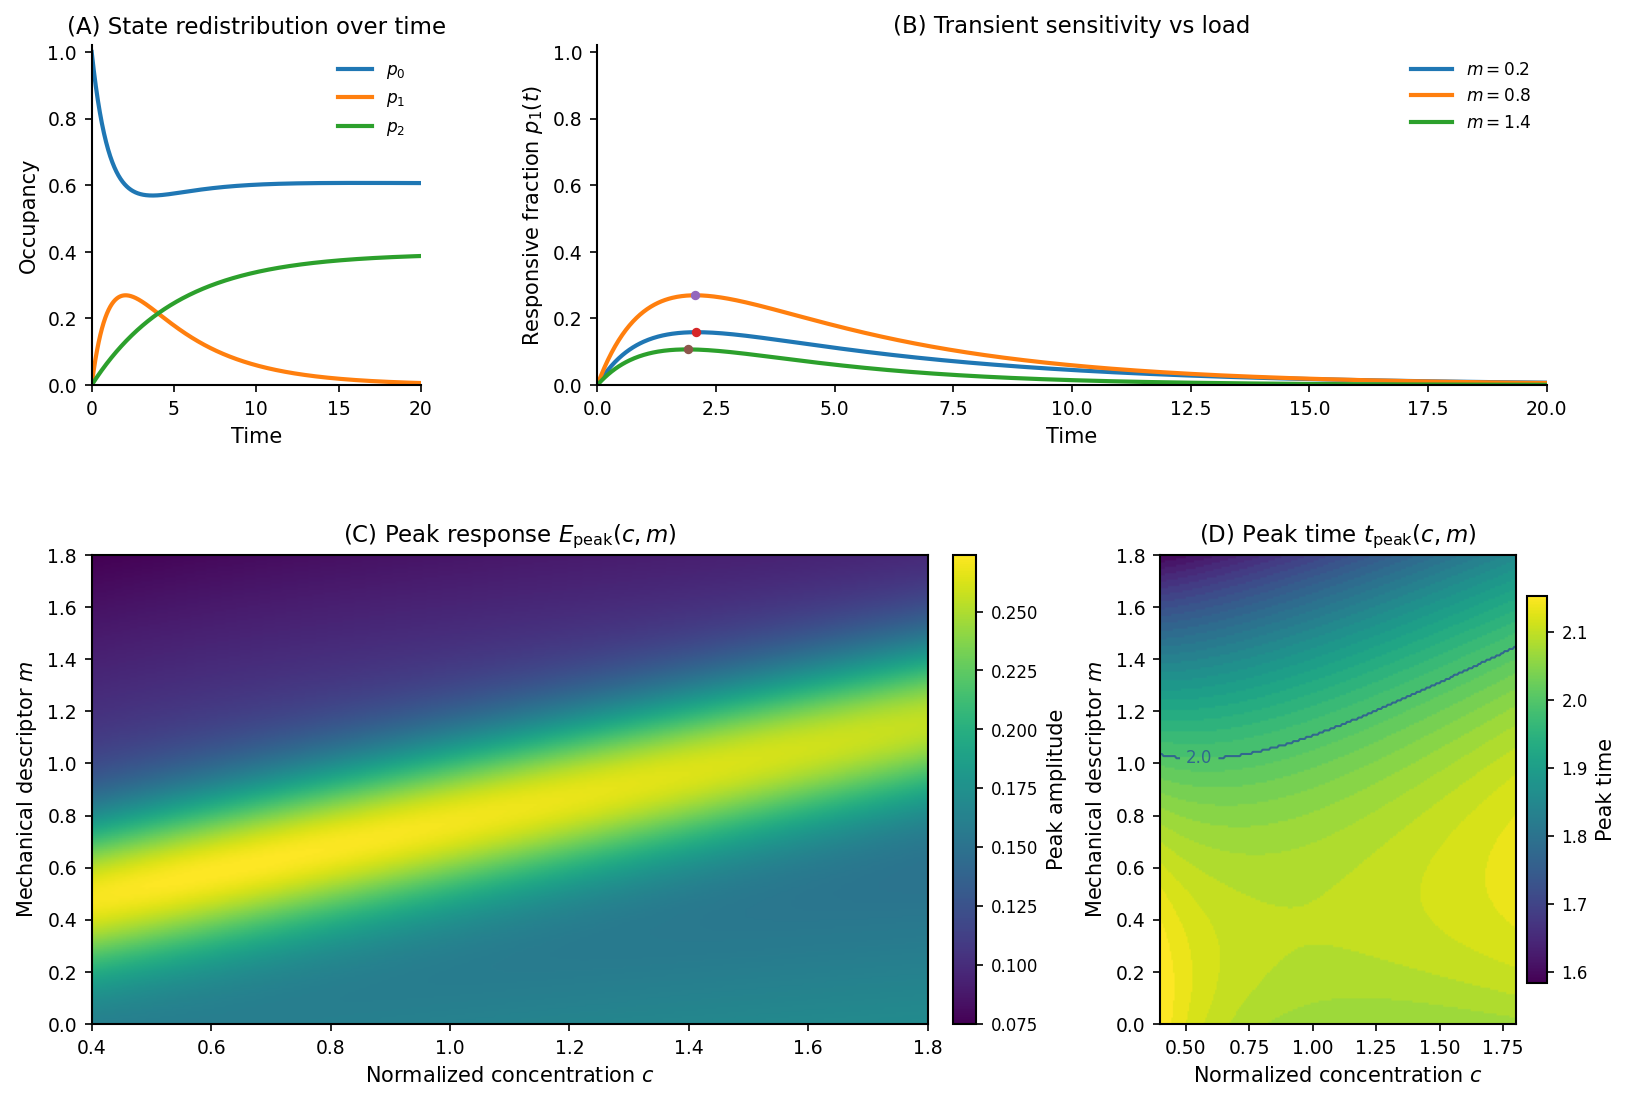

In [23]:
# fig4_transient_protection.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------------
# phenomenological transient three-state model
# -------------------------
def p1_curve(t, m, c=1.0):
    """
    Responsive state with early rise and delayed decay.
    Peak amplitude and peak time depend on both c and m.
    """
    amp = 0.28 + 0.30 * np.exp(-((m - (0.32 + 0.48 * c)) ** 2) / (2 * 0.22 ** 2))
    tau_fast = 1.0 + 0.45 * m + 0.18 / (c + 0.15)
    tau_esc  = 5.2 - 1.7 * m + 0.55 * c
    tau_esc = np.maximum(tau_esc, 1.3)
    return amp * (1 - np.exp(-t / tau_fast)) * np.exp(-t / tau_esc)

def p2_curve(t, m=0.8, c=1.0):
    """
    Protected state accumulates more slowly.
    """
    amp2 = 0.18 + 0.36 / (1 + np.exp(-4 * (m - 0.7)))
    tau2 = 5.5 - 1.2 * m + 0.6 * c
    tau2 = np.maximum(tau2, 1.5)
    return amp2 * (1 - np.exp(-t / tau2))

def p0_curve(t, m=0.8, c=1.0):
    p1 = p1_curve(t, m, c)
    p2 = p2_curve(t, m, c)
    p0 = 1.0 - p1 - p2
    return np.clip(p0, 0.0, 1.0)

def peak_metrics(c, m):
    """
    Return peak amplitude and peak time of p1(t).
    """
    t = np.linspace(0, 20, 1200)
    y = p1_curve(t, m, c)
    idx = np.argmax(y)
    return y[idx], t[idx]

# -------------------------
# grids for landscapes
# -------------------------
c_grid = np.linspace(0.4, 1.8, 220)
m_grid = np.linspace(0.0, 1.8, 220)
C, M = np.meshgrid(c_grid, m_grid)

Epeak = np.zeros_like(C)
Tpeak = np.zeros_like(C)

for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        Epeak[i, j], Tpeak[i, j] = peak_metrics(C[i, j], M[i, j])

# -------------------------
# layout
# top: A, B
# bottom: C, D
# B slightly emphasized by width
# -------------------------
fig = plt.figure(figsize=(10.9, 7.5))
gs = GridSpec(
    2, 3, figure=fig,
    height_ratios=[0.84, 1.16],
    width_ratios=[0.92, 1.08, 1.08],
    hspace=0.42, wspace=0.48
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1:])
axC = fig.add_subplot(gs[1, 0:2])
axD = fig.add_subplot(gs[1, 2])

# -------------------------
# (A) State redistribution over time
# -------------------------
axA.set_title("(A) State redistribution over time", pad=6)

t = np.linspace(0, 20, 800)
m_ref, c_ref = 0.8, 1.0

p0 = p0_curve(t, m_ref, c_ref)
p1 = p1_curve(t, m_ref, c_ref)
p2 = p2_curve(t, m_ref, c_ref)

axA.plot(t, p0, label=r"$p_0$")
axA.plot(t, p1, label=r"$p_1$")
axA.plot(t, p2, label=r"$p_2$")

axA.set_xlabel("Time")
axA.set_ylabel("Occupancy")
axA.set_xlim(0, 20)
axA.set_ylim(0, 1.02)
axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)
axA.legend(frameon=False, loc="upper right", handlelength=2.0)

# -------------------------
# (B) Transient sensitivity vs load
# -------------------------
axB.set_title("(B) Transient sensitivity vs load", pad=6)

m_values = [0.2, 0.8, 1.4]
for m in m_values:
    axB.plot(t, p1_curve(t, m, c=1.0), label=fr"$m={m:.1f}$")

axB.set_xlabel("Time")
axB.set_ylabel(r"Responsive fraction $p_1(t)$")
axB.set_xlim(0, 20)
axB.set_ylim(0, 1.02)
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.legend(frameon=False, loc="upper right", handlelength=2.4)

# light peak markers to highlight transient maximum
for m in m_values:
    y = p1_curve(t, m, c=1.0)
    idx = np.argmax(y)
    axB.plot(t[idx], y[idx], marker="o", ms=3.5)

# -------------------------
# (C) Peak response landscape Epeak(c,m)
# -------------------------
axC.set_title(r"(C) Peak response $E_{\mathrm{peak}}(c,m)$", pad=6)

imC = axC.imshow(
    Epeak,
    origin="lower",
    aspect="auto",
    extent=[c_grid.min(), c_grid.max(), m_grid.min(), m_grid.max()],
)

csC = axC.contour(C, M, Epeak, levels=[0.50, 0.60, 0.70, 0.80], linewidths=[0.8, 1.0, 1.2, 1.0])
axC.clabel(csC, inline=True, fontsize=8, fmt="%.2f")

axC.set_xlabel("Normalized concentration $c$")
axC.set_ylabel("Mechanical descriptor $m$")
axC.set_xlim(0.4, 1.8)
axC.set_ylim(0.0, 1.8)

cbC = fig.colorbar(imC, ax=axC, fraction=0.035, pad=0.028)
cbC.set_label("Peak amplitude")
cbC.ax.tick_params(labelsize=8)

# -------------------------
# (D) Peak time landscape tpeak(c,m)
# -------------------------
axD.set_title(r"(D) Peak time $t_{\mathrm{peak}}(c,m)$", pad=6)

imD = axD.imshow(
    Tpeak,
    origin="lower",
    aspect="auto",
    extent=[c_grid.min(), c_grid.max(), m_grid.min(), m_grid.max()],
)

csD = axD.contour(C, M, Tpeak, levels=[1.0, 2.0, 3.0, 4.0], linewidths=[0.8, 1.0, 1.2, 1.0])
axD.clabel(csD, inline=True, fontsize=8, fmt="%.1f")

axD.set_xlabel("Normalized concentration $c$")
axD.set_ylabel("Mechanical descriptor $m$")
axD.set_xlim(0.4, 1.8)
axD.set_ylim(0.0, 1.8)

cbD = fig.colorbar(imD, ax=axD, fraction=0.050, pad=0.03)
cbD.set_label("Peak time")
cbD.ax.tick_params(labelsize=8)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.97)

# Replace with the original filename if your TeX expects another name.
fig.savefig("fig4_transient.pdf")
print("Saved fig4_transient.pdf")
plt.show()

Saved fig5_signatures.pdf


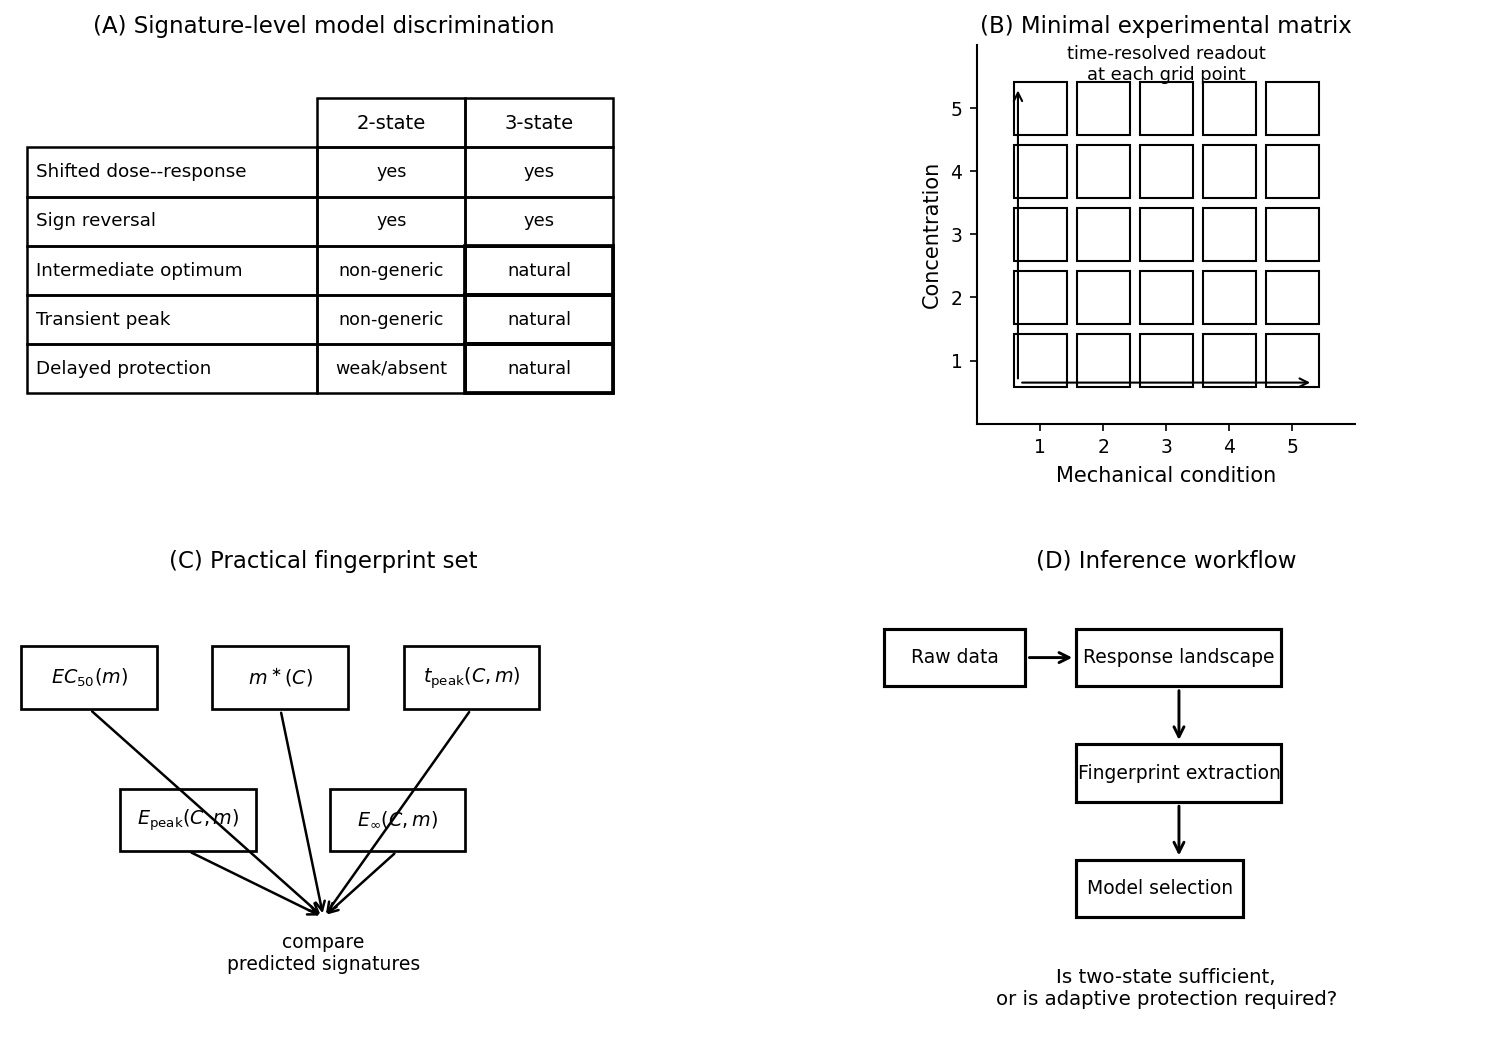

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(10.9, 7.5))
gs = GridSpec(
    2, 2, figure=fig,
    height_ratios=[0.92, 1.08],
    width_ratios=[1.04, 1.08],
    hspace=0.38, wspace=0.34
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

# -------------------------
# (A) Signature-level model discrimination
# -------------------------
axA.set_title("(A) Signature-level model discrimination", pad=6)
axA.axis("off")
axA.set_xlim(0, 1)
axA.set_ylim(0, 1)

rows = [
    "Shifted dose--response",
    "Sign reversal",
    "Intermediate optimum",
    "Transient peak",
    "Delayed protection",
]
data = [
    ["yes", "yes"],
    ["yes", "yes"],
    ["non-generic", "natural"],
    ["non-generic", "natural"],
    ["weak/absent", "natural"],
]

x0, y0 = 0.02, 0.08
w0, w1, w2 = 0.47, 0.24, 0.24
h = 0.13

for x, w in [(x0 + w0, w1), (x0 + w0 + w1, w2)]:
    axA.add_patch(Rectangle((x, y0 + 5*h), w, h, fill=False, lw=1.2))
axA.text(x0 + w0 + w1/2, y0 + 5.5*h, "2-state", ha="center", va="center", fontsize=9.4)
axA.text(x0 + w0 + w1 + w2/2, y0 + 5.5*h, "3-state", ha="center", va="center", fontsize=9.4)

for i, row in enumerate(rows):
    y = y0 + (4-i)*h
    axA.add_patch(Rectangle((x0, y), w0, h, fill=False, lw=1.2))
    axA.add_patch(Rectangle((x0 + w0, y), w1, h, fill=False, lw=1.2))
    axA.add_patch(Rectangle((x0 + w0 + w1, y), w2, h, fill=False, lw=1.2))

    axA.text(x0 + 0.014, y + h/2, row, ha="left", va="center", fontsize=8.8)
    axA.text(x0 + w0 + w1/2, y + h/2, data[i][0], ha="center", va="center", fontsize=8.4)
    axA.text(x0 + w0 + w1 + w2/2, y + h/2, data[i][1], ha="center", va="center", fontsize=8.6)

for idx in [2, 3, 4]:
    y = y0 + (4-idx)*h
    axA.add_patch(Rectangle((x0 + w0 + w1, y), w2, h, fill=False, lw=1.8))

# -------------------------
# (B) Minimal experimental matrix
# -------------------------
axB.set_title("(B) Minimal experimental matrix", pad=6)
axB.set_xlim(0, 6)
axB.set_ylim(0, 6)
axB.set_xlabel("Mechanical condition")
axB.set_ylabel("Concentration")
axB.set_aspect("equal")

for i in range(1, 6):
    for j in range(1, 6):
        axB.add_patch(Rectangle((j - 0.42, i - 0.42), 0.84, 0.84, fill=False, lw=1.0))

axB.set_xticks([1, 2, 3, 4, 5])
axB.set_yticks([1, 2, 3, 4, 5])
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)

axB.text(
    3.0, 5.70,
    "time-resolved readout\nat each grid point",
    ha="center", va="center", fontsize=8.6
)

axB.annotate("", xy=(5.35, 0.65), xytext=(0.65, 0.65),
             arrowprops=dict(arrowstyle="->", lw=1.0))
axB.annotate("", xy=(0.65, 5.35), xytext=(0.65, 0.65),
             arrowprops=dict(arrowstyle="->", lw=1.0))

# -------------------------
# (C) Practical fingerprint set
# -------------------------
axC.set_title("(C) Practical fingerprint set", pad=6)
axC.axis("off")
axC.set_xlim(0, 1)
axC.set_ylim(0, 1)

items = [
    (0.12, 0.78, r"$EC_{50}(m)$"),
    (0.43, 0.78, r"$m^\ast(C)$"),
    (0.74, 0.78, r"$t_{\mathrm{peak}}(C,m)$"),
    (0.28, 0.46, r"$E_{\mathrm{peak}}(C,m)$"),
    (0.62, 0.46, r"$E_{\infty}(C,m)$"),
]

box_w, box_h = 0.22, 0.14
for x, y, label in items:
    axC.add_patch(Rectangle((x - box_w/2, y - box_h/2), box_w, box_h, fill=False, lw=1.3))
    axC.text(x, y, label, ha="center", va="center", fontsize=9.2)

center_x, center_y = 0.50, 0.16
axC.text(center_x, center_y, "compare\npredicted signatures", ha="center", va="center", fontsize=9)

arrow_kw = dict(arrowstyle="->", mutation_scale=11, lw=1.2)
for x, y, _ in items:
    axC.add_patch(FancyArrowPatch((x, y - box_h/2), (center_x, center_y + 0.08), **arrow_kw))

# -------------------------
# (D) Inference workflow
# -------------------------
axD.set_title("(D) Inference workflow", pad=6)
axD.axis("off")
axD.set_xlim(0, 1)
axD.set_ylim(0, 1)

# widened and reorganized 2-step flow
boxes = [
    ("Raw data",               0.06, 0.76, 0.22, 0.13),
    ("Response landscape",     0.36, 0.76, 0.32, 0.13),
    ("Fingerprint extraction", 0.36, 0.50, 0.32, 0.13),
    ("Model selection",        0.36, 0.24, 0.26, 0.13),
]

for text, x, y, w, h in boxes:
    axD.add_patch(Rectangle((x, y), w, h, fill=False, lw=1.5))
    axD.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=9.0)

arrow_kw2 = dict(arrowstyle="->", mutation_scale=12, lw=1.4)
axD.add_patch(FancyArrowPatch((0.28, 0.825), (0.36, 0.825), **arrow_kw2))
axD.add_patch(FancyArrowPatch((0.52, 0.76), (0.52, 0.63), **arrow_kw2))
axD.add_patch(FancyArrowPatch((0.52, 0.50), (0.52, 0.37), **arrow_kw2))

axD.text(
    0.50, 0.08,
    "Is two-state sufficient,\nor is adaptive protection required?",
    ha="center", va="center", fontsize=9.5
)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.07, right=0.97)

fig.savefig("fig5_signatures.pdf")
print("Saved fig5_signatures.pdf")
plt.show()

In [ ]:
# Archive generated figures. In Google Colab, also trigger a browser download.
import zipfile
from pathlib import Path

figure_files = [
    'fig1_concept.pdf',
    'fig2_two_state.pdf',
    'fig3_three_state.pdf',
    'fig4_transient.pdf',
    'fig5_signatures.pdf',
]

zip_path = Path('figures.zip')
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for name in figure_files:
        path = Path(name)
        if path.exists():
            zf.write(path, arcname=path.name)
        else:
            print(f'Warning: {name} was not found and was not added.')

print(f'Created {zip_path.resolve()}')

try:
    from google.colab import files
except ModuleNotFoundError:
    print('Non-Colab environment detected; download figures.zip manually if needed.')
else:
    files.download(str(zip_path))
